# **Підготовка даних**

In [ ]:
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

import plotly.express as px
import pandas as pd

# налаштування розміру графіків за замовчуванням
plt.rcParams["figure.figsize"] = (12, 6)

print("Всі бібліотеки успішно імпортовані!)")

Всі бібліотеки успішно імпортовані!)


Завантажуємо MNIST

In [ ]:
print("Завантаження MNIST... ")
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
print("Датасет успішно завантажено!)")

Завантаження MNIST... 
Датасет успішно завантажено!)


Виведемо форму матриці X і кількість унікальних міток у y

In [ ]:
print(f"Форма матриці X: {X.shape}") # очікуємо (70000, 784)
print(f"Форма вектора y: {y.shape}") # очікуємо (70000,)
print(f"Унікальні класи: {np.unique(y)}") # очікуємо 0 1 2 3 4 5 6 7 8 9
print(f"Тип даних X: {X.dtype}") # float64 або uint8


Форма матриці X: (70000, 784)
Форма вектора y: (70000,)
Унікальні класи: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Тип даних X: int64


**Нормалізація даних**: Пікселі вмають значення у діапазоні 0-255, що відповідає інтенсивності яскравості. Для зручності подальшої обробки змасштабуємо їх до інтервалу 0-1, поділивши всі значення на 255

In [ ]:
X_normalized = X / 255.0
print("Після нормалізації:")
print(f"Мін. значення: {X_normalized.min():.3f}")  # 0
print(f"Макс. значення: {X_normalized.max():.3f}")  # 1
print(f"Середнє: {X_normalized.mean():.3f}")

Після нормалізації:
Мін. значення: 0.000
Макс. значення: 1.000
Середнє: 0.131


**Візуалізація прикладів**

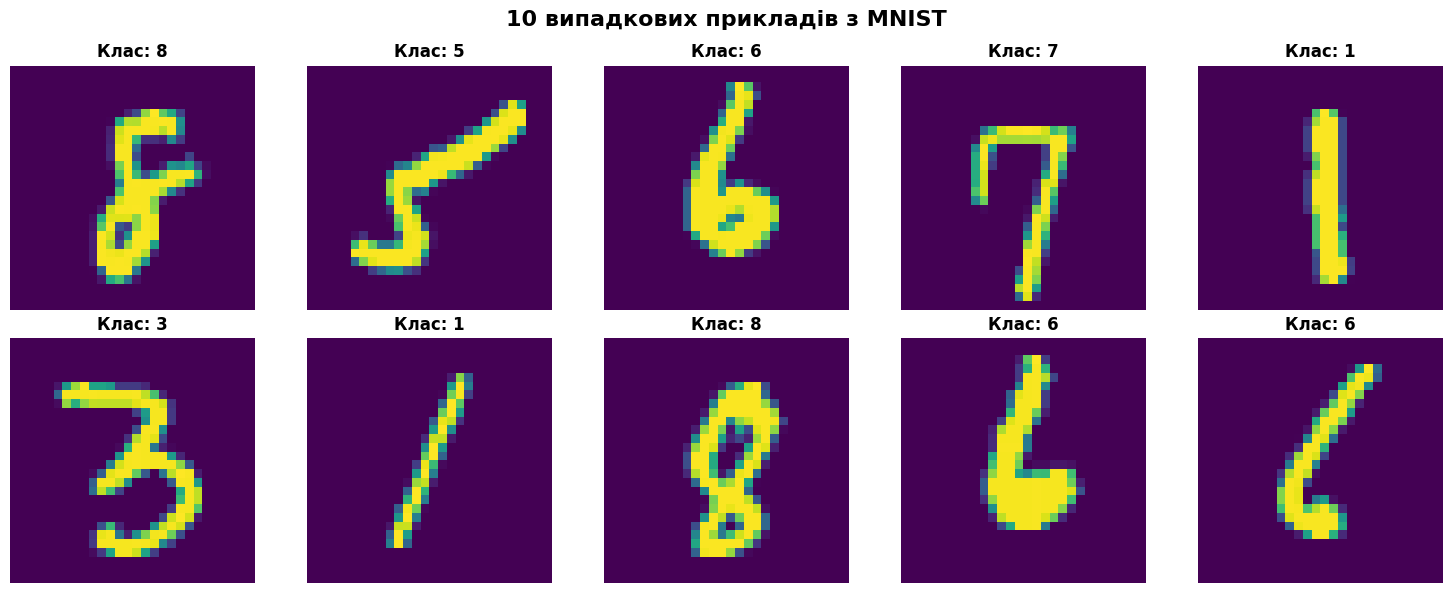

Мінімальне значення пікселів: 0.0
Максимальне значення пікселів: 1.0
Середнє значення пікселів: 0.13092535192648574


In [ ]:
np.random.seed(28) # для відтворюваності

# обираємо 10 випадкових індексів із 70000
random_indices = np.random.choice(len(X_normalized), size=10, replace=False)

# створюємо фігуру з 10 підграфіками в один ряд
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()  # перетворюємо 2D масив axes на 1D

for i, idx in enumerate(random_indices):
    # беремо i-тий рядок матриці X (784 числа)
    image_flat = X_normalized[idx]

    # reshape(28, 28) - перетворюємо рядок 784 пікселів назад у матрицю 28x28
    image_2d = image_flat.reshape(28, 28)

    axes[i].imshow(image_2d) # imshow показує матрицю як зображення
    axes[i].set_title(f"Клас: {y[idx]}", fontsize=12, fontweight="bold")
    axes[i].axis("off") # прибираємо осі координат

plt.suptitle("10 випадкових прикладів з MNIST", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("mnist_examples.png", dpi=150, bbox_inches="tight")
plt.show()

print("Мінімальне значення пікселів:", X_normalized.min())
print("Максимальне значення пікселів:", X_normalized.max())
print("Середнє значення пікселів:", X_normalized.mean())


# **Реалізація PCA**

In [ ]:
pca_3 = PCA(n_components=3) # 3 найважливіші компоненти

X_pca_3 = pca_3.fit_transform(X_normalized) # fit_transform = fit() + transform()
# fit() — знаходить головні компоненти (вивчає дані)
# transform() - проєктує дані на нові осі

# перевіряємо розмір
print(f"Форма X після PCA: {X_pca_3.shape}")  # матриця проєкцій(70000, 3)

# пояснена дисперсія
evr = pca_3.explained_variance_ratio_
print("\nВідсоток поясненої дисперсії:")
print(f"ГК1: {evr[0]*100:.2f}%")
print(f"ГК2: {evr[1]*100:.2f}%")
print(f"ГК3: {evr[2]*100:.2f}%")
print(f"Разом: {evr.sum()*100:.2f}%")

print("\nТобто:")
print(f"{evr.sum()*100:.1f}% варіабельності даних збережено у 3 компонентах")
print(f"{(1-evr.sum())*100:.1f}% інформації втрачено")


Форма X після PCA: (70000, 3)

Відсоток поясненої дисперсії:
ГК1: 9.75%
ГК2: 7.16%
ГК3: 6.15%
Разом: 23.05%

Тобто:
23.1% варіабельності даних збережено у 3 компонентах
76.9% інформації втрачено


# **Візуалізація дисперсії**

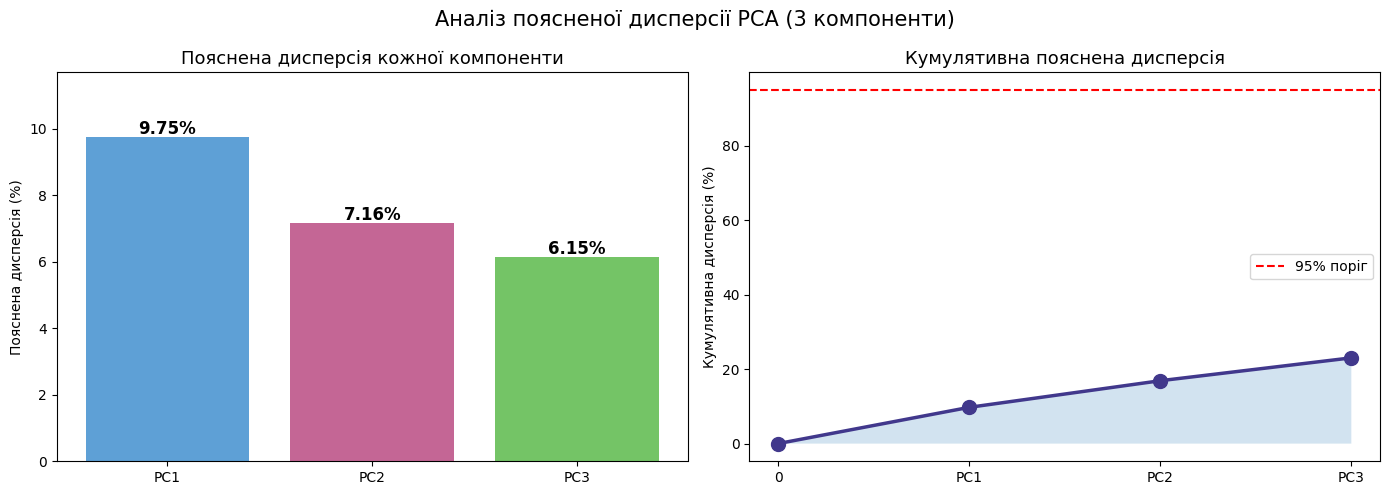

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# пояснена дисперсія кожної компоненти окремо
components = ["PC1", "PC2", "PC3"]
axes[0].bar(components, evr * 100, color=["#5ea0d6", "#c46695", "#74c466"])
axes[0].bar(components, evr * 100, color=["#5ea0d6", "#c46695", "#74c466"])

for i, val in enumerate(evr):
    axes[0].text(i, val*100 + 0.1, f"{val*100:.2f}%", ha="center", fontsize=12, fontweight="bold")
    axes[0].set_title("Пояснена дисперсія кожної компоненти", fontsize=13)
    axes[0].set_ylabel("Пояснена дисперсія (%)")
    axes[0].set_ylim(0, evr[0]*100 * 1.2)


# кумулятивна дисперсія
cumulative = np.cumsum(evr) * 100
axes[1].plot([0]+list(cumulative), "o-", color="#41388c", linewidth=2.5, markersize=10)
axes[1].fill_between(range(4), [0]+list(cumulative), alpha=0.2)
axes[1].axhline(y=95, color="red", linestyle="--", label="95% поріг")
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(["0", "PC1", "PC2", "PC3"])
axes[1].set_title("Кумулятивна пояснена дисперсія", fontsize=13)
axes[1].set_ylabel("Кумулятивна дисперсія (%)")
axes[1].legend()

plt.suptitle("Аналіз поясненої дисперсії PCA (3 компоненти)", fontsize=15)
plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()

# **3D-візуалізація у просторі головних компонент**

In [ ]:
n_show = 5000
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca_3), size=n_show, replace=False)
X_sample = X_pca_3[sample_idx]
y_sample = y[sample_idx].astype(int)

df_plot = pd.DataFrame({ "PC1": X_sample[:, 0], "PC2": X_sample[:, 1], "PC3": X_sample[:, 2], "Цифра": y_sample.astype(str) })

fig_plotly = px.scatter_3d( #для 3D-точкового графіку
    df_plot,
    x="PC1", y="PC2", z="PC3",
    color="Цифра",
    title="3D-візуалізація за допомогою PCA (5000 точок)",
    opacity=0.6,
    width=900, height=700,
    color_discrete_sequence=px.colors.qualitative.T10 )

fig_plotly.update_traces(marker=dict(size=3))
fig_plotly.update_layout(legend_title="Цифра")

fig_plotly.show()

fig_plotly.write_html("pca_3d_interactive.html")


Цифри 0 та 1 утворюють відносно чіткі кластери відокремлені від решти. Інші цифри можуть перекриватися. Видно загальну структуру, але перекриття присутнє. 3 компоненти зберігають лише ~23% інформації.

# **Реконструкція зображень**


Форма реконструйованих даних: (70000, 784)


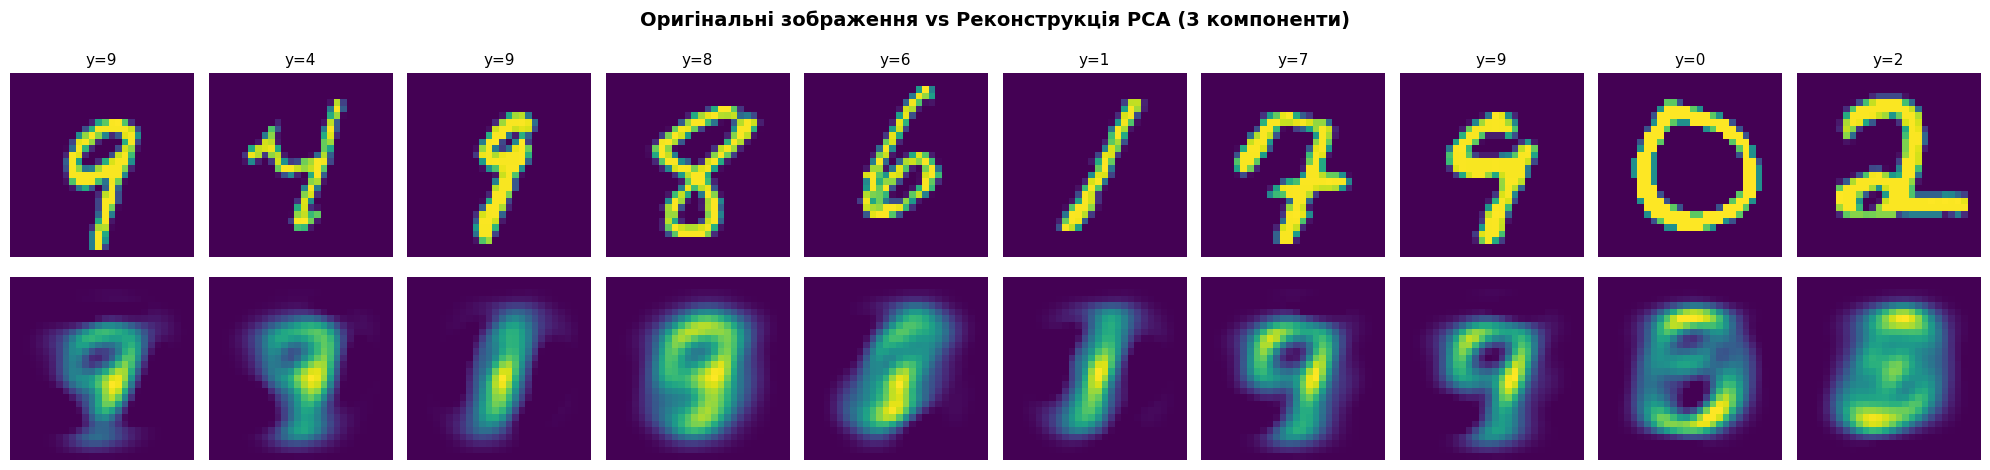


MSE при k=3 компонентах: 0.051772


In [ ]:
# X_pca_3 зараз має форму (70000, 3)
X_reconstructed_3 = pca_3.inverse_transform(X_pca_3) # переводить назад у простір (70000, 784)

print(f"Форма реконструйованих даних: {X_reconstructed_3.shape}") # очікуємо (70000, 784)

# обираємо 10 випадкових прикладів
np.random.seed(8)
sample_idx_rec = np.random.choice(len(X_normalized), size=10, replace=False)

# малюємо попарно оригінал та реконструкція
fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for col, idx in enumerate(sample_idx_rec):
    # верх - оригінальне зображення
    axes[0, col].imshow(X_normalized[idx].reshape(28, 28))
    axes[0, col].set_title(f"y={y[idx]}", fontsize=11)
    axes[0, col].axis("off")

    # низ - реконструйоване зображення
    # clip(0, 1) - обрізаємо значення поза [0,1] (можуть виникнути через PCA)
    axes[1, col].imshow(X_reconstructed_3[idx].reshape(28, 28).clip(0, 1))
    axes[1, col].axis("off")

# підписи рядків
axes[0, 0].set_ylabel("Оригінал", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("PCA (k=3)", fontsize=12, fontweight="bold")

plt.suptitle("Оригінальні зображення vs Реконструкція PCA (3 компоненти)",fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("reconstruction_3components.png", dpi=150, bbox_inches="tight")
plt.show()

# обчислення MSE для 3 компонент
mse_3 = np.mean((X_normalized - X_reconstructed_3) ** 2)
print(f"\nMSE при k=3 компонентах: {mse_3:.6f}")


# **Аналіз залежності MSE від кількості компонент**

Очікувана поведінка: При k=1: найбільша помилка MSE, найгірша реконструкція; При більшому k: MSE = 0 (ідеальне відновлення, адже нічого не викинули); Між першою та останьою точками: MSE монотонно спадає; у певний момент - перегин, де додавання компонент вже мало допомагає

In [ ]:
np.random.seed(42)
n_sample = 10000
idx_sub = np.random.choice(len(X_normalized), size=n_sample, replace=False)
X_sub = X_normalized[idx_sub]

# діапазон кількостей компонент для тестування
k_values = [1, 2, 3, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 500, 700]

mse_list = [] # MSE для кожного k
var_ratio_list = [] # сума explained_variance_ratio_ для кожного k

print("Обчислення PCA для різних k...")
for k in k_values:
    print(f"  k = {k}...", end=" ")

    # створюємо та навчаємо PCA
    pca_k = PCA(n_components=k)
    X_pca_k = pca_k.fit_transform(X_sub)

    # зворотна трансформація
    X_rec_k = pca_k.inverse_transform(X_pca_k)

    # MSE = середнє((оригінал - реконструкція)^2)
    mse = np.mean((X_sub - X_rec_k) ** 2)
    mse_list.append(mse)

    # сумарна пояснена дисперсія
    var_ratio_list.append(pca_k.explained_variance_ratio_.sum())

    print(f"MSE={mse:.6f}, Дисперсія={var_ratio_list[-1]*100:.1f}%")

print("\nГотово!)))")


Обчислення PCA для різних k...
  k = 1... MSE=0.060482, Дисперсія=9.8%
  k = 2... MSE=0.055704, Дисперсія=16.9%
  k = 3... MSE=0.051604, Дисперсія=23.1%
  k = 5... MSE=0.044730, Дисперсія=33.3%
  k = 10... MSE=0.034215, Дисперсія=49.0%
  k = 20... MSE=0.023794, Дисперсія=64.5%
  k = 30... MSE=0.017933, Дисперсія=73.3%
  k = 50... MSE=0.011656, Дисперсія=82.6%
  k = 75... MSE=0.007748, Дисперсія=88.4%
  k = 100... MSE=0.005631, Дисперсія=91.6%
  k = 150... MSE=0.003379, Дисперсія=95.0%
  k = 200... MSE=0.002178, Дисперсія=96.8%
  k = 300... MSE=0.000878, Дисперсія=98.7%
  k = 500... MSE=0.000045, Дисперсія=99.9%
  k = 700... MSE=0.000000, Дисперсія=100.0%

Готово!)))


# **Аналіз залежності якості PCA від кількості компонент**

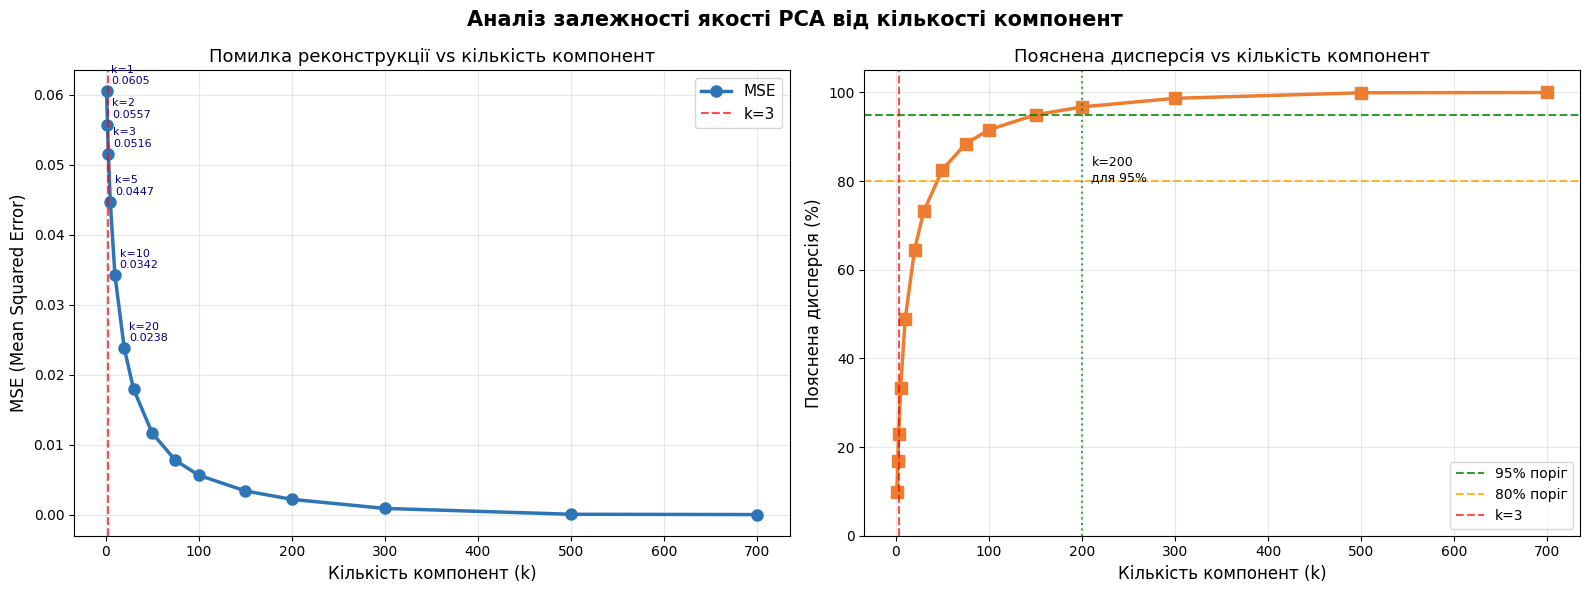

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MSE vs k
axes[0].plot(k_values, mse_list, "o-", color="#2E75B6", linewidth=2.5, markersize=8, label="MSE")
axes[0].axvline(x=3, color="red", linestyle="--", alpha=0.7, label="k=3")

for k, mse in zip(k_values[:6], mse_list[:6]): axes[0].annotate(f"k={k}\n{mse:.4f}", xy=(k, mse), xytext=(k+5, mse+0.001), fontsize=8, color="navy")

axes[0].set_xlabel("Кількість компонент (k)", fontsize=12)
axes[0].set_ylabel("MSE (Mean Squared Error)", fontsize=12)
axes[0].set_title("Помилка реконструкції vs кількість компонент", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# пояснена дисперсія vs k
axes[1].plot(k_values, [v*100 for v in var_ratio_list], "s-", color="#ED7D31", linewidth=2.5, markersize=8)
axes[1].axhline(y=95, color="green", linestyle="--", alpha=0.8, label="95% поріг")
axes[1].axhline(y=80, color="orange", linestyle="--", alpha=0.8, label="80% поріг")
axes[1].axvline(x=3, color="red", linestyle="--", alpha=0.7, label="k=3")

# знаходимо k для 95% дисперсії
for i, v in enumerate(var_ratio_list):
    if v >= 0.95:
        k95 = k_values[i]
        axes[1].axvline(x=k95, color="green", linestyle=":", alpha=0.7)
        axes[1].annotate(f"k={k95}\nдля 95%", xy=(k95, 95), xytext=(k95+10, 80), fontsize=9)
        break

axes[1].set_xlabel("Кількість компонент (k)", fontsize=12)
axes[1].set_ylabel("Пояснена дисперсія (%)", fontsize=12)
axes[1].set_title("Пояснена дисперсія vs кількість компонент", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 105)

plt.suptitle("Аналіз залежності якості PCA від кількості компонент", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("mse_vs_components.png", dpi=150, bbox_inches="tight")
plt.show()


# **Реконструкція зображень після зменшення розмірності**

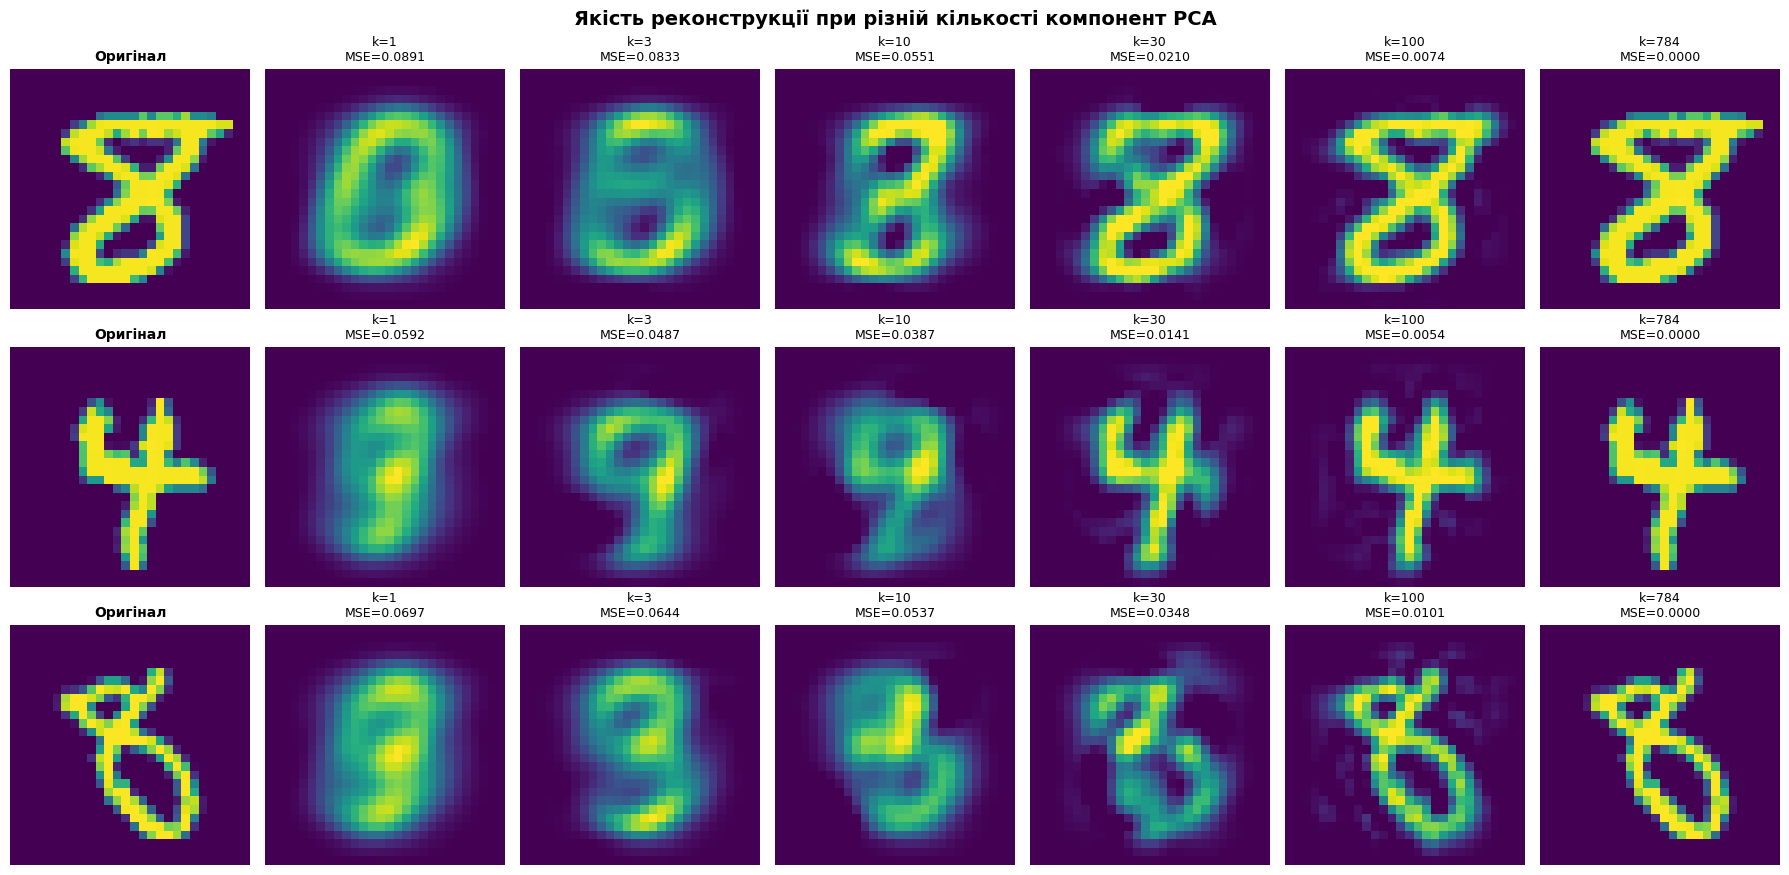

In [ ]:
test_indices = [0, 1, 2]  # перші 3 зображення з вибірки
k_compare = [1, 3, 10, 30, 100, 784]

fig, axes = plt.subplots(len(test_indices), len(k_compare)+1, figsize=(18, 3*len(test_indices)))

for row, img_idx in enumerate(test_indices):
    # перший стовпець оригінал
    axes[row, 0].imshow(X_sub[img_idx].reshape(28, 28))
    axes[row, 0].set_title("Оригінал", fontsize=10, fontweight="bold")
    axes[row, 0].axis("off")

    for col, k in enumerate(k_compare, start=1):
        # реконструюємо з k компонентами
        pca_temp = PCA(n_components=k)
        X_temp_pca = pca_temp.fit_transform(X_sub)
        X_temp_rec = pca_temp.inverse_transform(X_temp_pca)

        # реконструкція конкретного зображення
        rec_img = X_temp_rec[img_idx].reshape(28, 28).clip(0, 1)
        axes[row, col].imshow(rec_img)

        mse_k = np.mean((X_sub[img_idx] - X_temp_rec[img_idx])**2)
        axes[row, col].set_title(f"k={k}\nMSE={mse_k:.4f}", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Якість реконструкції при різній кількості компонент PCA",fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("reconstruction_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
